# Etapa 2 — EDA 01: Qualidade e perfil da camada Silver

Este notebook faz uma auditoria **somente leitura** dos datasets Silver consolidados no MinIO. Ele não cria, altera ou remove objetos do data lake.

Objetivos: inventariar schemas e cobertura; verificar nulos, duplicidades e chaves; testar integridade entre fatos; e evidenciar a inconsistência de 2020 para Interlagos.

## 1. Ambiente e conexão

Execute esta célula com o MinIO em execução (`docker compose up -d`). O DuckDB lê os Parquets diretamente do bucket, sem materializar cópias locais.

In [4]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid', context='notebook')

MINIO_ENDPOINT = 'localhost:9000'
MINIO_ACCESS_KEY = 'admin'
MINIO_SECRET_KEY = 'minioadmin123'
BUCKET = 'f1-data-lake'
SILVER_BASE = f's3://{BUCKET}/silver/consolidado'

DUCKDB_EXTENSION_DIR = Path.cwd() / '.duckdb_extensions'
DUCKDB_EXTENSION_DIR.mkdir(exist_ok=True)
con = duckdb.connect(config={'extension_directory': str(DUCKDB_EXTENSION_DIR)})
con.execute('INSTALL httpfs')
con.execute('LOAD httpfs')
con.execute(f"""
    SET s3_endpoint='{MINIO_ENDPOINT}';
    SET s3_access_key_id='{MINIO_ACCESS_KEY}';
    SET s3_secret_access_key='{MINIO_SECRET_KEY}';
    SET s3_use_ssl=false;
    SET s3_url_style='path';
""")

print('Conexão DuckDB/MinIO configurada.')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Conexão DuckDB/MinIO configurada.


## 2. Registro dos datasets e regras de qualidade

As chaves abaixo são chaves lógicas definidas nos scripts de pré-processamento. A coluna `escopo_interlagos` evita usar o calendário completo como se todas as suas corridas tivessem fatos detalhados.

In [6]:
DATASETS = {
    'calendario': {'pk': ['season', 'round'], 'escopo_interlagos': True},
    'resultados': {'pk': ['season', 'round', 'driver_id']},
    'voltas': {'pk': ['season', 'round', 'lap', 'driver_id']},
    'pit_stops': {'pk': ['season', 'round', 'driver_id', 'stop']},
    'pneus': {'pk': ['season', 'session', 'driver_id', 'lap_number']},
    'clima': {'pk': ['season', 'session', 'weather_time_seconds']},
}

for nome, regra in DATASETS.items():
    caminho = f"{SILVER_BASE}/{nome}.parquet"
    con.execute(f"CREATE OR REPLACE VIEW {nome} AS SELECT * FROM read_parquet('{caminho}')")

# Views analíticas: 2020 é excluído dos fatos FastF1 porque não houve corrida em Interlagos.
con.execute("CREATE OR REPLACE VIEW calendario_interlagos AS SELECT * FROM calendario WHERE circuit_id = 'interlagos'")
con.execute("CREATE OR REPLACE VIEW pneus_validos AS SELECT * FROM pneus WHERE season <> 2020")
con.execute("CREATE OR REPLACE VIEW clima_valido AS SELECT * FROM clima WHERE season <> 2020")
con.execute("CREATE OR REPLACE VIEW driver_mapping as SELECT * FROM driver_mapping")
con.execute("CREATE OR REPLACE VIEW voltas as SELECT * FROM voltas")

print('Views Silver carregadas:', ', '.join(DATASETS))

Views Silver carregadas: calendario, resultados, voltas, pit_stops, pneus, clima


## 3. Inventário: volume, período e schema

Esta seção confirma o contrato físico dos dados antes de qualquer análise estatística.

In [3]:
inventario = []
for nome in DATASETS:
    colunas = con.sql(f"DESCRIBE {nome}").df()
    resumo = con.sql(f"SELECT COUNT(*) AS linhas, MIN(season) AS temporada_inicial, MAX(season) AS temporada_final, COUNT(DISTINCT season) AS temporadas FROM {nome}").df().iloc[0]
    inventario.append({
        'dataset': nome,
        'linhas': resumo['linhas'],
        'colunas': len(colunas),
        'temporada_inicial': resumo['temporada_inicial'],
        'temporada_final': resumo['temporada_final'],
        'temporadas': resumo['temporadas'],
        'pk_logica': ', '.join(DATASETS[nome]['pk']),
    })

pd.DataFrame(inventario).sort_values('dataset')

,dataset,linhas,colunas,temporada_inicial,temporada_final,temporadas,pk_logica
0,calendario,233,19,2015,2025,11,"season, round"
5,clima,1256,17,2018,2025,8,"season, session, weather_time_seconds"
3,pit_stops,295,20,2015,2025,10,"season, round, driver_id, stop"
4,pneus,9892,15,2018,2025,8,"season, session, driver_id, lap_number"
1,resultados,202,36,2015,2025,10,"season, round, driver_id"
2,voltas,12589,20,2015,2025,10,"season, round, lap, driver_id"


In [4]:
for nome in DATASETS:
    print(f'\n### {nome.upper()}')
    display(con.sql(f"DESCRIBE {nome}").df())


### CALENDARIO


,column_name,column_type,null,key,default,extra
0,season,BIGINT,YES,None,None,None
1,round,INTEGER,YES,None,None,None
2,race_name,VARCHAR,YES,None,None,None
3,race_date,DATE,YES,None,None,None
4,race_time,VARCHAR,YES,None,None,None
5,race_time_millis,BIGINT,YES,None,None,None
6,race_url,VARCHAR,YES,None,None,None
7,circuit_id,VARCHAR,YES,None,None,None
8,circuit_name,VARCHAR,YES,None,None,None
9,circuit_url,VARCHAR,YES,None,None,None



### RESULTADOS


,column_name,column_type,null,key,default,extra
0,season,BIGINT,YES,None,None,None
1,round,INTEGER,YES,None,None,None
2,race_name,VARCHAR,YES,None,None,None
3,race_date,DATE,YES,None,None,None
4,race_time,VARCHAR,YES,None,None,None
5,race_time_millis,BIGINT,YES,None,None,None
6,circuit_id,VARCHAR,YES,None,None,None
7,circuit_name,VARCHAR,YES,None,None,None
8,circuit_lat,DOUBLE,YES,None,None,None
9,circuit_long,DOUBLE,YES,None,None,None



### VOLTAS


...

,column_name,column_type,null,key,default,extra
0,season,BIGINT,YES,None,None,None
1,round,INTEGER,YES,None,None,None
2,race_name,VARCHAR,YES,None,None,None
3,race_date,DATE,YES,None,None,None
4,race_time,TIME,YES,None,None,None
5,race_time_millis,BIGINT,YES,None,None,None
6,race_url,VARCHAR,YES,None,None,None
7,circuit_id,VARCHAR,YES,None,None,None
8,circuit_name,VARCHAR,YES,None,None,None
9,circuit_url,VARCHAR,YES,None,None,None



### PNEUS


,column_name,column_type,null,key,default,extra
0,season,BIGINT,YES,None,None,None
1,grand_prix,VARCHAR,YES,None,None,None
2,circuit,VARCHAR,YES,None,None,None
3,session,VARCHAR,YES,None,None,None
4,session_name,VARCHAR,YES,None,None,None
5,event_name,VARCHAR,YES,None,None,None
6,location,VARCHAR,YES,None,None,None
7,event_date,DATE,YES,None,None,None
8,driver_id,VARCHAR,YES,None,None,None
9,driver_number,INTEGER,YES,None,None,None



### CLIMA


,column_name,column_type,null,key,default,extra
0,season,BIGINT,YES,None,None,None
1,grand_prix,VARCHAR,YES,None,None,None
2,circuit,VARCHAR,YES,None,None,None
3,session,VARCHAR,YES,None,None,None
4,session_name,VARCHAR,YES,None,None,None
5,event_name,VARCHAR,YES,None,None,None
6,location,VARCHAR,YES,None,None,None
7,event_date,DATE,YES,None,None,None
8,weather_time_seconds,DOUBLE,YES,None,None,None
9,weather_time_millis,BIGINT,YES,None,None,None


## 4. Cobertura por temporada e alerta de 2020

A ausência de fatos Jolpica em 2020 é esperada. A existência de `pneus` e `clima` nesse ano é o alerta de qualidade a ser confirmado.

dataset,calendario,clima,pit_stops,pneus,resultados,voltas
season,,,,,,
2015,19,0,30,0,20,1327
2016,21,0,30,0,22,1292
2017,20,0,30,0,20,1167
2018,21,125,25,1318,20,1318
2019,21,131,30,1385,20,1381
2020,17,139,0,1077,0,0
2021,22,158,30,1360,20,1360
2022,22,167,30,1259,20,1256
2023,22,183,30,1108,20,1106


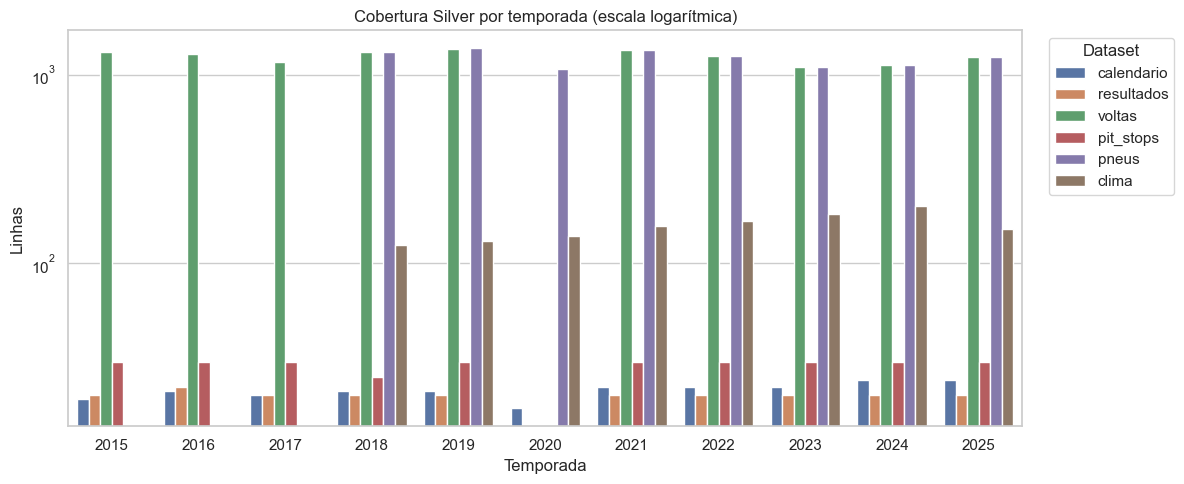

,dataset,season,linhas
43,pneus,2020,1077
51,clima,2020,139


In [5]:
cobertura = pd.concat([
    con.sql(f"SELECT '{nome}' AS dataset, season, COUNT(*) AS linhas FROM {nome} GROUP BY season").df()
    for nome in DATASETS
], ignore_index=True)

display(cobertura.pivot(index='season', columns='dataset', values='linhas').fillna(0).astype('int64'))

plt.figure(figsize=(12, 5))
sns.barplot(data=cobertura, x='season', y='linhas', hue='dataset', errorbar=None)
plt.yscale('log')
plt.title('Cobertura Silver por temporada (escala logarítmica)')
plt.xlabel('Temporada')
plt.ylabel('Linhas')
plt.legend(title='Dataset', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

alerta_2020 = cobertura.query("season == 2020 and dataset in ['pneus', 'clima']")
display(alerta_2020)

## 5. Nulos e duplicidades

Nulos são avaliados em todas as colunas. Duplicidades são avaliadas estritamente pela chave lógica de cada dataset.

,coluna,nulos,dataset,percentual_nulo
0,third_practice_date,24.0,calendario,10.300429
1,second_practice_date,18.0,calendario,7.725322
19,race_time_millis,81.0,resultados,40.099010
20,race_time,81.0,resultados,40.099010
21,fastest_lap_average_speed,33.0,resultados,16.336634
22,fastest_lap_average_speed_unit,33.0,resultados,16.336634
23,fastest_lap_rank,14.0,resultados,6.930693
24,fastest_lap,14.0,resultados,6.930693
25,fastest_lap_time_millis,14.0,resultados,6.930693
26,fastest_lap_time,14.0,resultados,6.930693


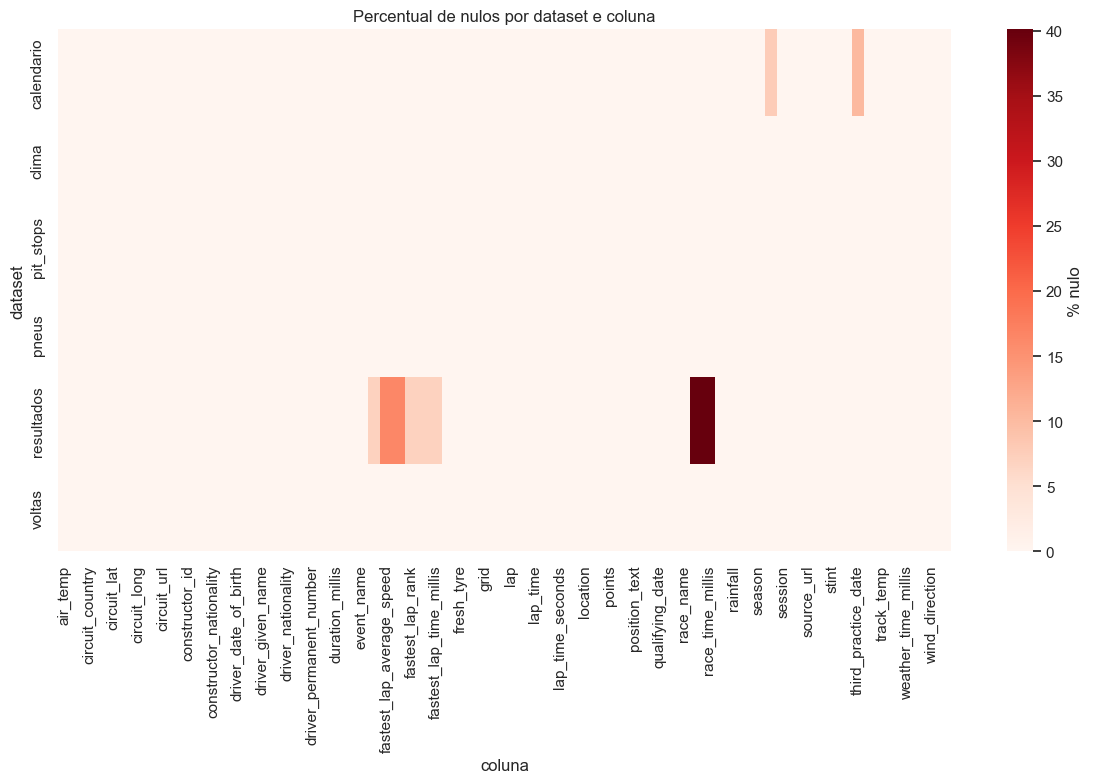

In [6]:
def perfil_nulos(nome):
    colunas = con.sql(f"DESCRIBE {nome}").df()['column_name'].tolist()
    expressoes = ', '.join(
        f"SUM(CASE WHEN \"{coluna}\" IS NULL THEN 1 ELSE 0 END) AS \"{coluna}\""
        for coluna in colunas
    )
    total = con.sql(f"SELECT COUNT(*) FROM {nome}").fetchone()[0]
    resultado = con.sql(f"SELECT {expressoes} FROM {nome}").df().melt(var_name='coluna', value_name='nulos')
    resultado['dataset'] = nome
    resultado['percentual_nulo'] = 100 * resultado['nulos'] / total if total else 0
    return resultado.sort_values('percentual_nulo', ascending=False)

nulos = pd.concat([perfil_nulos(nome) for nome in DATASETS], ignore_index=True)
display(nulos.query('nulos > 0').sort_values(['dataset', 'percentual_nulo'], ascending=[True, False]))

plt.figure(figsize=(12, 8))
matriz_nulos = nulos.pivot(index='dataset', columns='coluna', values='percentual_nulo').fillna(0)
sns.heatmap(matriz_nulos, cmap='Reds', cbar_kws={'label': '% nulo'})
plt.title('Percentual de nulos por dataset e coluna')
plt.tight_layout()
plt.show()

In [7]:
duplicidades = []
for nome, regra in DATASETS.items():
    chave = ', '.join(regra['pk'])
    consulta = f"""
        SELECT COUNT(*) AS grupos_duplicados, COALESCE(SUM(quantidade - 1), 0) AS linhas_excedentes
        FROM (
            SELECT {chave}, COUNT(*) AS quantidade
            FROM {nome}
            GROUP BY {chave}
            HAVING COUNT(*) > 1
        )
    """
    resultado = con.sql(consulta).df().iloc[0].to_dict()
    resultado['dataset'] = nome
    duplicidades.append(resultado)

pd.DataFrame(duplicidades)[['dataset', 'grupos_duplicados', 'linhas_excedentes']].sort_values('dataset')

,dataset,grupos_duplicados,linhas_excedentes
0,calendario,0.0,0.0
5,clima,0.0,0.0
3,pit_stops,0.0,0.0
4,pneus,0.0,0.0
1,resultados,0.0,0.0
2,voltas,0.0,0.0


## 6. Integridade referencial

As métricas abaixo contam registros órfãos. Para pneus, o teste é indicativo: a chave de evento não contém `round`, por isso o vínculo é feito por temporada, piloto e volta.

In [8]:
testes_integridade = {
    'resultados sem corrida no calendário de Interlagos': """
        SELECT COUNT(*) FROM resultados r
        WHERE NOT EXISTS (SELECT 1 FROM calendario_interlagos c WHERE c.season = r.season AND c.round = r.round)
    """,
    'voltas sem resultado do piloto': """
        SELECT COUNT(*) FROM voltas v
        WHERE NOT EXISTS (SELECT 1 FROM resultados r WHERE r.season=v.season AND r.round=v.round AND r.driver_id=v.driver_id)
    """,
    'pit stops sem resultado do piloto': """
        SELECT COUNT(*) FROM pit_stops p
        WHERE NOT EXISTS (SELECT 1 FROM resultados r WHERE r.season=p.season AND r.round=p.round AND r.driver_id=p.driver_id)
    """,
    'pneus válidos sem volta correspondente': """
        SELECT COUNT(*) FROM pneus_validos p
        WHERE NOT EXISTS (SELECT 1 FROM voltas v WHERE v.season=p.season AND v.driver_id=p.driver_id AND v.lap=p.lap_number)
    """,
}

integridade = pd.DataFrame([
    {'teste': descricao, 'registros_orfaos': con.sql(consulta).fetchone()[0]}
    for descricao, consulta in testes_integridade.items()
])
integridade

,teste,registros_orfaos
0,resultados sem corrida no calendário de Interl...,0
1,voltas sem resultado do piloto,0
2,pit stops sem resultado do piloto,0
3,pneus válidos sem volta correspondente,8815


## 7. Regras específicas e conclusão da etapa

Além dos testes genéricos, verificamos domínios básicos. Valores fora dessas faixas não são automaticamente removidos: são sinalizados para investigação.

In [9]:
regras_dominio = {
    'posição final inválida': 'SELECT COUNT(*) FROM resultados WHERE position IS NOT NULL AND position < 1',
    'pontos negativos': 'SELECT COUNT(*) FROM resultados WHERE points < 0',
    'tempo de volta não positivo': 'SELECT COUNT(*) FROM voltas WHERE lap_time_seconds IS NOT NULL AND lap_time_seconds <= 0',
    'duração de pit stop não positiva': 'SELECT COUNT(*) FROM pit_stops WHERE duration IS NOT NULL AND duration <= 0',
    'vida de pneu negativa': 'SELECT COUNT(*) FROM pneus_validos WHERE tyre_life IS NOT NULL AND tyre_life < 0',
    'umidade fora de 0–100': 'SELECT COUNT(*) FROM clima_valido WHERE humidity IS NOT NULL AND (humidity < 0 OR humidity > 100)',
}

dominios = pd.DataFrame([
    {'regra': regra, 'ocorrencias': con.sql(consulta).fetchone()[0]}
    for regra, consulta in regras_dominio.items()
])
display(dominios)

print('Critérios para avançar à EDA descritiva:')
print('- Nenhuma duplicidade nas PKs lógicas;')
print('- Órfãos explicados ou ausentes;')
print('- Partições FastF1 de 2020 excluídas da análise;')
print('- Nulos e domínios críticos documentados antes de calcular estatísticas.')

,regra,ocorrencias
0,posição final inválida,0
1,pontos negativos,0
2,tempo de volta não positivo,0
3,duração de pit stop não positiva,0
4,vida de pneu negativa,0
5,umidade fora de 0–100,0


Critérios para avançar à EDA descritiva:
- Nenhuma duplicidade nas PKs lógicas;
- Órfãos explicados ou ausentes;
- Partições FastF1 de 2020 excluídas da análise;
- Nulos e domínios críticos documentados antes de calcular estatísticas.
